# Data preprocessing and network building

Load data from C:\Users\TZ\repo\gnn\data\trans_sample.csv

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r'C:\Users\TZ\repo\gnn\data\trans_sample.csv.gz', compression="gzip")

In [4]:
df.head(5)

,bank_from,acct_from,bank_to,acct_to,date,amt
0,A306732E0,B19676F40,9C7A02740,B19676D10,2019-01-31,115.43
1,A1D342960,B19664770,8604EE500,B19668520,2019-01-31,2.85
2,803A70E80,8066F9560,8025799A0,806EE7500,2019-01-20,15057.01
3,9D31C3340,B19687690,82E78C7F0,B19687370,2019-01-31,-1739.79
4,8051EF8E0,94DF22CA0,91D2F9C10,B1969F4D0,2019-01-31,2087.74


In [3]:
# revert from and to account and bank if transaction amount is negative

mask = df['amt'] < 0
df.loc[mask, ['acct_from', 'acct_to', 'bank_from', 'bank_to']] = df.loc[mask, ['acct_to', 'acct_from', 'bank_to', 'bank_from']].values
df['amt'] = df['amt'].abs()

In [4]:
from sklearn.preprocessing import StandardScaler

df['amt_log'] = np.log1p(df['amt'])

scaler = StandardScaler()
df['amt_scaled'] = scaler.fit_transform(df[['amt_log']])

In [5]:
from gnn.data import to_graph
from gnn.vis import plot_transaction_graph

C:\Users\TZ\AppData\Local\Temp\ipykernel_16248\1775206905.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


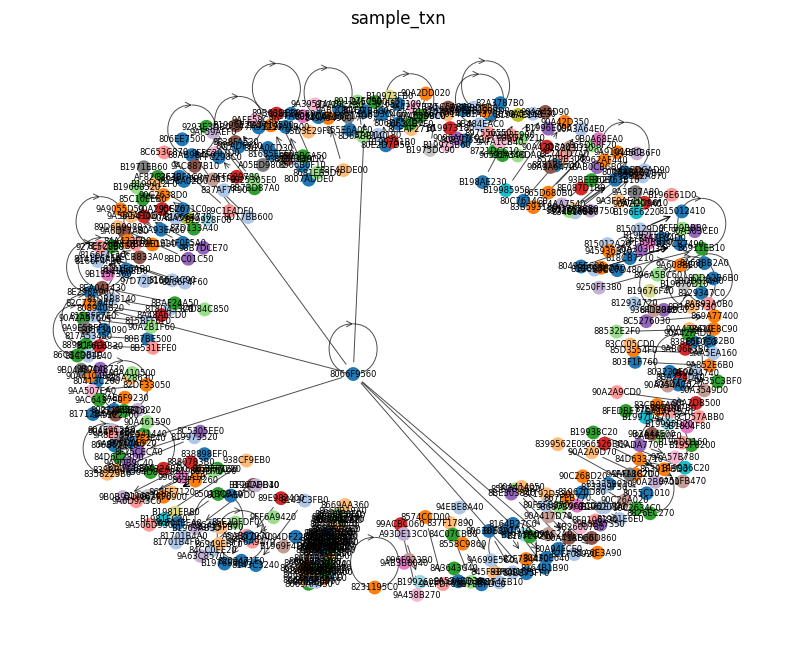

In [6]:
# Build the transaction graph
graph = to_graph(df, {
  "src_account": "acct_from",
  "dst_account": "acct_to",
  "src_bank": "bank_from",
  "dst_bank": "bank_to",
  "amount": "amt_scaled",
  # "target": "label",          # uncomment if you have labels
  "metadata_label": "sample_txn"
})

fig, ax = plot_transaction_graph(graph, max_edges=300, seed=42, color_by_bank=True)
fig.show()

In [7]:
cfg = {
  "type": "gcn",           # or "gat" / "sage"
  "hidden_dims": [32, 32],
  "in_channels": graph.x.shape[1],
  "out_channels": 2,       # adjust to your label space
}

train_cfg = {
  "lr": 1e-3,
  "epochs": 5,
  "device": "auto",     # "cpu" (default), "auto" (GPU if available), or "cuda:0"
}

model = build_model(cfg)
metrics, trained = train(model, graph, None, train_cfg)
print(metrics, next(trained.parameters()).device)

NameError: name 'build_model' is not defined